# **Program 1**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_csv as rd

In [ ]:
df=rd('EDAibm_hr_employee-attrition.csv')

In [ ]:
num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns

In [ ]:
n=input("Enter the number col")
if n in num:
    col=df[n]
    mean=col.mean()
    median=col.median()
    mode=col.mode()
    std=col.std()
    var=col.var()
    range=col.max()-col.min()
    q1=col.quantile(0.25)
    q3=col.quantile(0.75)
    iqr=q3-q1
    lb=q1-(1.5*iqr)
    ub=q3+(1.5*iqr)
    outliers=col[(col<lb)|(col>lb)]
    print(f"Mean: {mean}\nMedian: {median}\nMode: {mode}\nStandard Deviation: {std}\nVariance: {var}\nRange: {range}\n\nOutliers: {len(outliers)}")
else:
    print("Not a number column")

Mean: 36.923809523809524
Median: 36.0
Mode: 0    35
Name: Age, dtype: int64
Standard Deviation: 9.135373489136734
Variance: 83.45504878602227
Range: 42

Outliers: 1470


<Axes: xlabel='Age', ylabel='Count'>

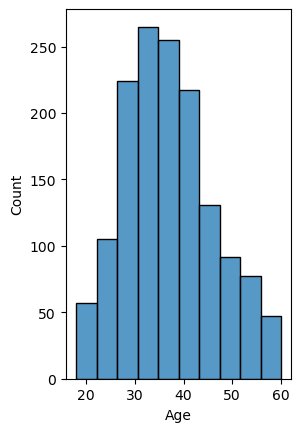

In [ ]:
plt.subplot(1,2,1)
sns.histplot(col,bins=10)


<Axes: ylabel='Age'>

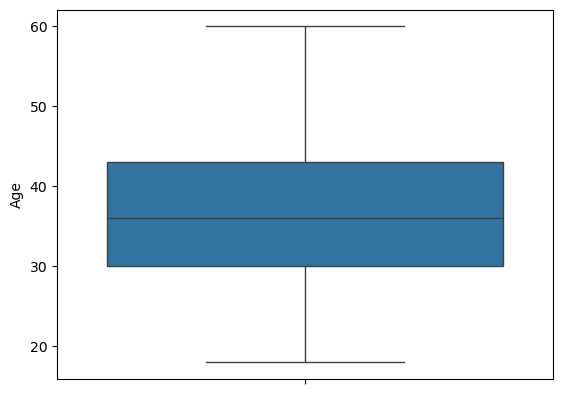

In [ ]:
sns.boxplot(col)

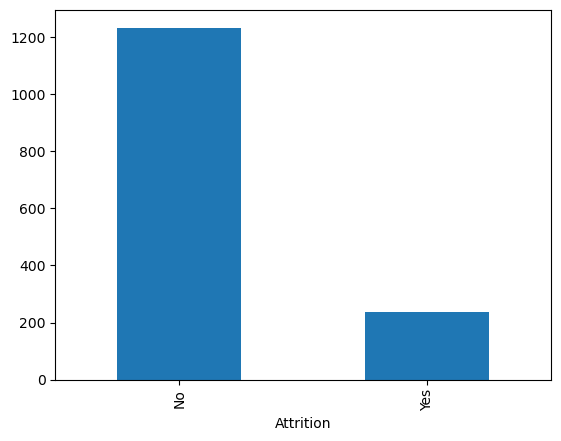

In [ ]:
c=input("Enter the cat col")
if c in cat:
    col=df[c].value_counts()
    cho=input("Enter the type of plot bar for bar pie for pie")
    if cho.lower() == 'bar':
        col.plot(kind='bar')
    elif cho.lower() == 'pie':
        col.plot(kind='pie')
    else:
        print("Invalid choice")
else:
    print("Invalid column name")

# **Program 2**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df=sns.load_dataset('iris')
x='petal_length'
y='sepall_length'

In [ ]:
corr=df[['petal_length','sepal_length']].corr('pearson')
cov=df[['petal_length','sepal_length']].cov()
print(f'{cov} \n{corr}')

              petal_length  sepal_length
petal_length      3.116278      1.274315
sepal_length      1.274315      0.685694 
              petal_length  sepal_length
petal_length      1.000000      0.871754
sepal_length      0.871754      1.000000


In [ ]:
d=df.iloc[:,:-1]
cov=d.cov()
corr=d.corr()

<Axes: >

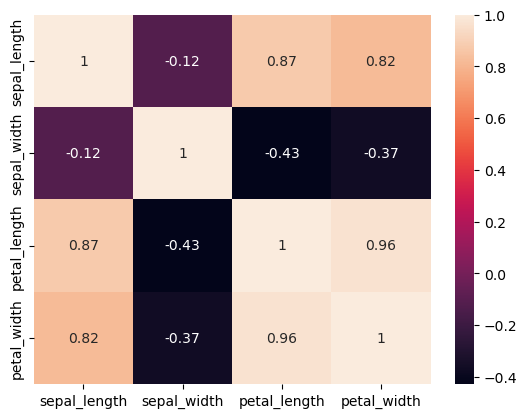

In [ ]:
sns.heatmap(corr,annot=True)

# **Program 3**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
iris=load_iris()
x=iris.data
y=iris.target

In [ ]:
ss=StandardScaler()
td1=ss.fit_transform(x)

In [ ]:
pc=PCA(n_components=2)
td2=pc.fit_transform(td1)

In [ ]:
color=['red','greeen','blue']
pdf=pd.DataFrame(td2,columns=['PC1','PC2'])
pdf['Species']=y

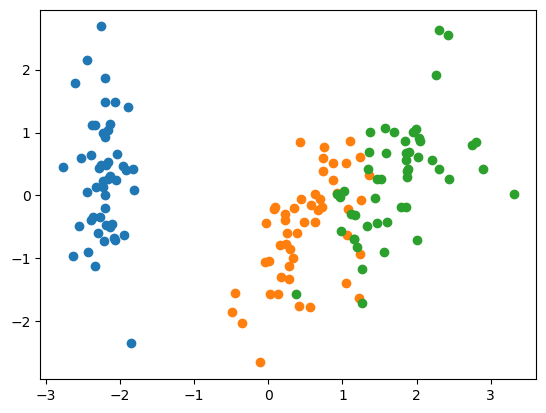

In [ ]:
for i, color in zip([0,1,2],color):
    plt.scatter(
        pdf[pdf['Species']==i]['PC1'],
        pdf[pdf['Species']==i]['PC2']
    )
plt.plot()
plt.show()

# **Program 4**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as tts
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as ass, f1_score as f1
from sklearn.datasets import load_iris

In [ ]:
iris=load_iris()
x=iris.data; y=iris.target
k_val=[1,3,5]


In [ ]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)

In [ ]:
def nei (x_train,x_test,y_train,y_test,k_val,weighted=False):
    results={}
    for k in k_val:
        if weighted:
            knn=KNeighborsClassifier(n_neighbors=k,weights='distance')
        else:
            knn=KNeighborsClassifier(n_neighbors=k,weights='uniform')
        knn.fit(x_train,y_train)
        y_pred=knn.predict(x_test)
        acc=ass(y_test,y_pred)
        f11=f1(y_test,y_pred,average='weighted')
        results[k]={
            'acc':acc,
            'f1':f11
        }
    return results

In [ ]:
wk=nei(x_train,x_test,y_train,y_test,k_val,weighted=True)
for k,m in wk.items():
    print(f"{k}, {m['acc']}, {m['f1']}")

1, 1.0, 1.0
3, 1.0, 1.0
5, 1.0, 1.0


In [ ]:
nwk=nei(x_train,x_test,y_train,y_test,k_val,weighted=False)
for i,m in nwk.items():
    print(f"{i}, {m['acc']}, {m['f1']}")

1, 1.0, 1.0
3, 1.0, 1.0
5, 1.0, 1.0


In [ ]:
for k in k_val:
    wa= wk[k]['acc']
    na=nwk[k]['acc']
    print(f"{k}, {wa}, {na}")

1, 1.0, 1.0
3, 1.0, 1.0
5, 1.0, 1.0


# **Program 5**

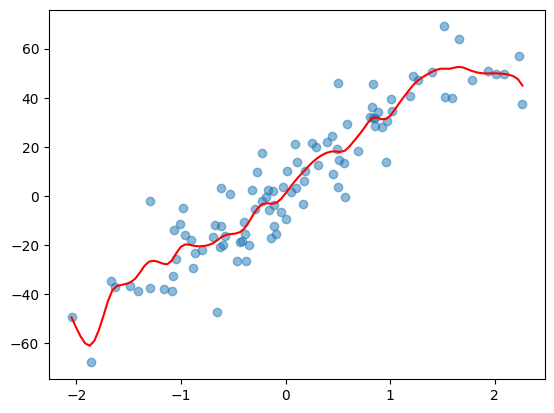

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
x,y=make_regression(n_samples=100,n_features=1,noise=10,random_state=43)
y+=10*np.sin(x[:,0]**2)
x_test=np.linspace(x.min(),x.max(),100)
def lin(x,y,q,tau=0.1):
  w=np.exp(-((x-q)**2).sum(axis=1)/(2*tau**2))
  wp=np.diag(w)
  x_b=np.c_[np.ones(len(x)),x]
  qb=[1,q]
  theta=np.linalg.lstsq(x_b.T @wp @x_b, x_b.T @wp @y, rcond=True)[0]
  return qb @ theta
t=0.1
y_pred=[lin(x,y,q,t)for q in x_test]
plt.scatter(x,y,alpha=0.5)
plt.plot(x_test,y_pred,color='r')
plt.show()

# **Program 6**

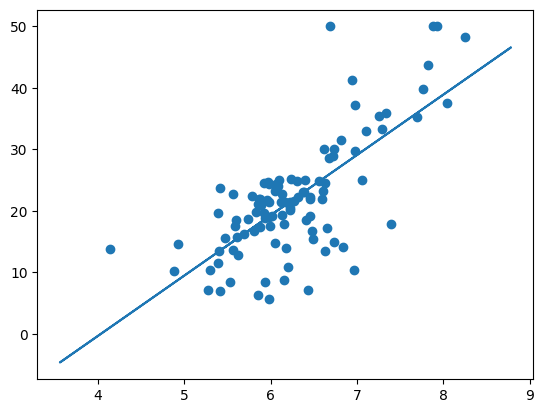

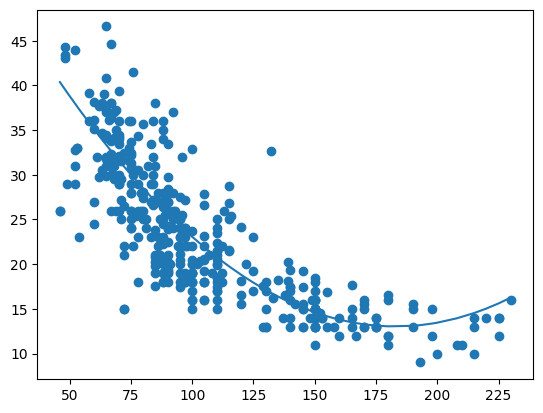

In [27]:
from os import XATTR_REPLACE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df=pd.read_csv('/content/boston_housing_data.csv')
x=df[['RM']]
y=df[['MEDV']]
x_test,x_train,y_test,y_train=tts(x,y,test_size=0.2,random_state=43)
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
plt.scatter(x_train,y_train)
plt.plot(x_test,y_pred)
plt.show()
df=pd.read_csv('/content/auto-mpg.csv')
df['horsepower'] = auto_df['horsepower'].replace('?', np.nan).astype(float)
df.dropna(inplace=True)
x = df[['horsepower']]
y = df['mpg']
x_test,x_train,y_test,y_train=tts(x,y,test_size=0.2,random_state=43)
p=PolynomialFeatures(degree=2)
x_train_p=p.fit_transform(x_train)
x_test_p=p.transform(x_test)
lr.fit(x_train_p,y_train)
y_pred=lr.predict(x_test_p)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
plt.scatter(x,y)
sor=x_test.squeeze().argsort()
plt.plot(x_test.iloc[sor],y_pred[sor])
plt.show()

# **Program 7**

0.8041958041958042
0.72


/tmp/ipykernel_1992/3165588313.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
/tmp/ipykernel_1992/3165588313.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex']=df['sex'].map({'male':0,'female':1})
/tmp/ipykernel_1992/3165588313.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['

[Text(0.45689655172413796, 0.9, 'x[1] <= 0.5\ngini = 0.486\nsamples = 569\nvalue = [332, 237]'),
 Text(0.1896551724137931, 0.7, 'x[2] <= 6.5\ngini = 0.334\nsamples = 359\nvalue = [283, 76]'),
 Text(0.3232758620689655, 0.8, 'True  '),
 Text(0.06896551724137931, 0.5, 'x[3] <= 2.5\ngini = 0.388\nsamples = 19\nvalue = [5, 14]'),
 Text(0.034482758620689655, 0.3, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.10344827586206896, 0.3, 'x[4] <= 1.5\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.06896551724137931, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.13793103448275862, 0.1, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3103448275862069, 0.5, 'x[0] <= 1.5\ngini = 0.298\nsamples = 340\nvalue = [278, 62]'),
 Text(0.2413793103448276, 0.3, 'x[2] <= 43.5\ngini = 0.472\nsamples = 84\nvalue = [52, 32]'),
 Text(0.20689655172413793, 0.1, 'gini = 0.5\nsamples = 45\nvalue = [22, 23]'),
 Text(0.27586206896551724, 0.1, 'gini = 0.355\nsamples = 39\nvalue = [30, 9]'),
 Te

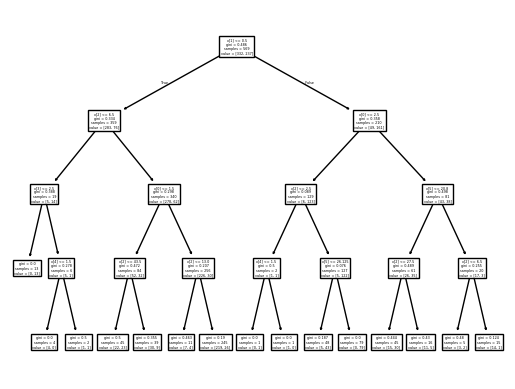

In [109]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score as acc, f1_score as f1
from sklearn.model_selection import train_test_split as tts
data=sns.load_dataset('titanic')
f=['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare','embarked']
df=data[f]
df.dropna(inplace=True)
df['sex']=df['sex'].map({'male':0,'female':1})
df['embarked']=df['embarked'].map({'S':0,'Q':1,'C':3})
y=df['survived']
x=df.drop(columns=['survived'])
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
cls=DecisionTreeClassifier(max_depth=4)
cls.fit(x_train,y_train)
y_pred=cls.predict(x_test)
print(f"{acc(y_test,y_pred)}\n{f1(y_test,y_pred)}")
plot_tree(cls)

# **Program 8**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.89      1.00      0.94         8
           2       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



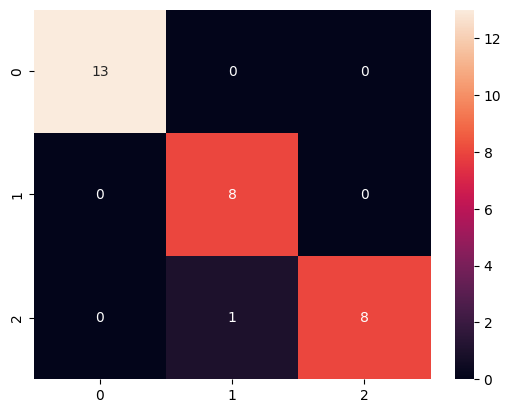

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix as cmm, classification_report as crr
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split as tts
data=load_iris()
x=data.data
y=data.target
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
gb=GaussianNB()
gb.fit(x_train,y_train)
y_pred=gb.predict(x_test)
print(crr(y_test,y_pred))
cm=cmm(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()


# **Program 9**

0.34338224069077816
0.6536246043910179


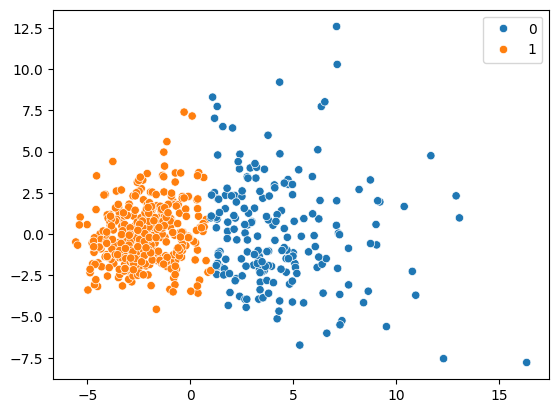

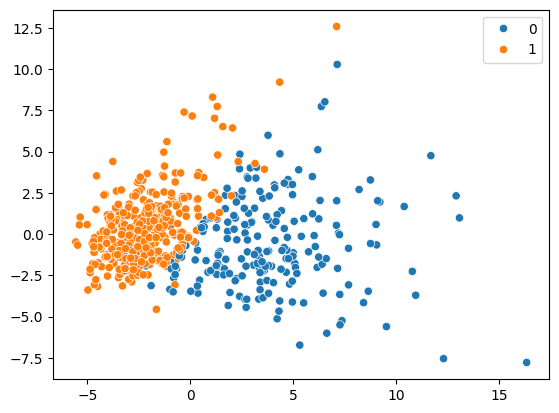

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as si, adjusted_rand_score as ad
data=load_breast_cancer()
x=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target
s=StandardScaler()
x_s=s.fit_transform(x)
k=KMeans(n_clusters=2,random_state=43)
y_m=k.fit_predict(x_s)
print(f"{si(x_s,y_m)}\n{ad(y,y_m)}")
sns.scatterplot(x=x_p[:,0],y=x_p[:,1],hue=y_m)
plt.show()
sns.scatterplot(x=x_p[:,0],y=x_p[:,1],hue=y)
plt.show()